# Lab 07: Genetic Algorithms

## Total: 50 points

In this lab, you'll explore the fundamentals of genetic algorithms by implementing core operations like selection, crossover, and mutation. We give you the initialization code and fitness function so you can focus the different ways to implement core operations.

## General Instructions

- Carefully read through the commented helper functions.
- Implement the missing functions where marked with `pass`.
- This lab is VERY open ended! There isn't one way to do this. Implement the strategies or verisons that interest you!
- **We have provided suggested parameters to pass into the unimplemented functions, but depending on the methods you pick, the parameters might change or you will need additional ones. Make sure to edit the parameter list for methods and strategies you use!!** 

In [55]:
import random
import matplotlib.pyplot as plt
import time

In [56]:
# Problem Constants
NUM_PEOPLE = 5
SHIFTS_PER_DAY = 3
DAYS_PER_WEEK = 7
SHIFTS_PER_WEEK = SHIFTS_PER_DAY * DAYS_PER_WEEK # 21

In [57]:
# GA Parameters
POPULATION_SIZE = 100       # Number of schedules in each generation
GENERATIONS = 150           # Number of generations to run
MUTATION_RATE = 0.02        # Probability of a single bit flip mutation
CROSSOVER_RATE = 0.7        # Probability that crossover occurs between two parents
HARD_PENALTY = -2           # Penalty per violated hard constraint
SOFT_PENALTY = -1           # Penalty per violated soft constraint

# Helper Functions

In [58]:
## Helper Functions
def get_shift_details(shift_index):
    """
    Calculates day (0-6) and shift type (0=M, 1=A, 2=N) from shift index (0-20).

    Args:
        shift_index (int): The shift index (0-20)

    Returns:
        day (int): The day of the week (0-6)
        shift_type (int): The shift type (0=M, 1=A, 2=N)
    """
    if not (0 <= shift_index < SHIFTS_PER_WEEK):
        raise ValueError(f"shift_index {shift_index} out of range [0, {SHIFTS_PER_WEEK-1}]")
    day = shift_index // SHIFTS_PER_DAY
    shift_type = shift_index % SHIFTS_PER_DAY
    return day, shift_type

def print_schedule(schedule, fitness):
    """
    Prints the schedule in a readable format.

    Args:
        schedule (list): The schedule to print
        fitness (float): The fitness score of the schedule
    """
    print(f"\nSchedule (Fitness: {fitness:.2f}):")
    days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
    shifts = ["M", "A", "N"]
    header = "      " + " | ".join([days[d] for d in range(DAYS_PER_WEEK)])
    print(header)
    subheader = "      " + " ".join([f"{s}" for _ in days for s in shifts])
    print(subheader)
    print("      " + "-" * (len(subheader)-1))
    for person_idx, person_schedule in enumerate(schedule):
        schedule_str = ""
        for i in range(SHIFTS_PER_WEEK):
             schedule_str += str(person_schedule[i])
             if (i + 1) % SHIFTS_PER_DAY == 0 and i < SHIFTS_PER_WEEK - 1:
                 schedule_str += " " # Add space between days
        print(f"ATC {person_idx+1}: {schedule_str}")
    print("-" * (len(subheader) + 5))

def plot_fitness(fitness_history):
    """
    Plots the best and average fitness score per generation.

    Args:
        fitness_history (list): A list of fitness scores for each generation

    Returns:
        None
    """
    plt.figure(figsize=(12, 6))
    generations = range(1, len(fitness_history) + 1)
    plt.plot(generations, fitness_history, marker='o', linestyle='-', label='Best Fitness')
    plt.title('GA Fitness Progression for ATC Scheduling')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Score (Higher is Better)')
    # Set y-limit to start slightly below the minimum fitness achieved or a reasonable lower bound
    min_fitness = min(fitness_history)
    plt.ylim(bottom=min(min_fitness - 5, -50)) # Adjust y-axis floor
    plt.legend()
    plt.grid(True)
    plt.show()

## Initialization

Helper code to create the initial population. Make sure you understand how we have chosen to represent the individual and population!

In [59]:
# Init GA
def generate_initial_representation(num_people, shifts_per_week):
  """
  Creates a single random schedule representation (chromosome).
  Each person gets a list of 0s and 1s for the week's shifts.

  Args:
    num_people (int): The number of people in the schedule.
    shifts_per_week (int): The number of shifts per week.

  Returns:
    schedule (list): A list of lists, where each inner list represents a person's schedule for the week.
  """
  schedule = []
  for _ in range(num_people):
    person_schedule = [random.choice([0, 1]) for _ in range(shifts_per_week)]
    schedule.append(person_schedule)
  return schedule

def generate_population(population_size, num_people, shifts_per_week):
  """ Creates the initial population of random schedules. """
  return [generate_initial_representation(num_people, shifts_per_week)
          for _ in range(population_size)]

## Fitness Function

Evaluate how close a candidate is to the target solution. Note how hard versus soft constraints are handled.

In [99]:
def evaluate_fitness(schedule, num_people, shifts_per_week, shifts_per_day):
    """ 
    Calculates the fitness of a single schedule based on constraints. 

    Args:
        schedule (list): The schedule to evaluate
        num_people (int): The number of people in the schedule
        shifts_per_week (int): The number of shifts per week
        shifts_per_day (int): The number of shifts per day

    Returns:
        fitness (float): The fitness score of the schedule
    """
    fitness = 0 # Start with perfect fitness, subtract penalties

    # Hard Constraint Checks

    # 1. Minimum controllers per shift
    min_controllers = {0: 1, 1: 2, 2: 1} # M:1, A:2, N:1
    shift_violations = 0
    for shift_idx in range(shifts_per_week):
        _, shift_type = get_shift_details(shift_idx)

        # Calculate number of controllers on this shift
        controllers_on_shift = sum(schedule[p][shift_idx] for p in range(num_people))
        required = min_controllers[shift_type]

        # Penalize for each missing controller
        if controllers_on_shift < required:
            fitness += HARD_PENALTY * (required - controllers_on_shift)
            shift_violations += (required - controllers_on_shift)

    # 2. Rest periods
    rest_violations = 0
    for p in range(num_people):
        for shift_idx in range(shifts_per_week):
            if schedule[p][shift_idx] == 1: # If person p works this shift
                _, shift_type = get_shift_details(shift_idx)

                # a) Rest after Morning (0) or Afternoon (1)
                if shift_type in [0, 1]:
                    next_shift_idx = shift_idx + 1
                    # Check boundary: ensure next shift is within the week
                    if next_shift_idx < shifts_per_week and schedule[p][next_shift_idx] == 1:
                         fitness += HARD_PENALTY # Violation: Working the very next shift
                         rest_violations += 1

                # b) Rest after Night (2)
                elif shift_type == 2:
                    # Check the next 3 shifts (full day)
                    violation_found_for_night_shift = False
                    for i in range(1, shifts_per_day + 1):
                        next_shift_idx = shift_idx + i
                        # Check boundary: ensure check stays within the week
                        if next_shift_idx < shifts_per_week and schedule[p][next_shift_idx] == 1:
                            if not violation_found_for_night_shift: # Only penalize once per night shift violation
                                fitness += HARD_PENALTY
                                rest_violations += 1
                                violation_found_for_night_shift = True
                            # No need to check further shifts for *this* night shift once violation is found

    # Soft Constraint Checks

    # 1. Excess controllers in tower
    excess_violations = 0
    for shift_idx in range(shifts_per_week):
        _, shift_type = get_shift_details(shift_idx)
        controllers_on_shift = sum(schedule[p][shift_idx] for p in range(num_people))
        required = min_controllers[shift_type]
        if controllers_on_shift > required:
            excess = controllers_on_shift - required
            fitness += SOFT_PENALTY * excess # Penalize for each extra controller
            excess_violations += excess

    # A fitness of 0 means no constraints were violated. Higher (less negative) is better.
    # You could also return the counts of violations for analysis if needed:
    # return fitness, shift_violations, rest_violations, excess_violations
    return fitness

## Q1.1 Parent Selection (4 points)

In this step, pick the parents chosen for crossover. Recall there are lots of different ways this can fit together with the crossover step. It's up to you on which method you pick.

In [ ]:
def parent_selection(population, fitness_scores):
    """
    Selects two parents using tournament selection.

    Args:
        population (list): The current generation of schedules.
        fitness_scores (list): Fitness values corresponding to each schedule.

    Returns:
        tuple: Two selected parent schedules for crossover.
    """
    tournament_size = 3
    selected_parents = []
    for _ in range(2):
        contenders = random.sample(list(zip(population, fitness_scores)), tournament_size)
        winner = max(contenders, key=lambda x: x[1])[0]
        selected_parents.append(winner)
    return selected_parents[0], selected_parents[1]


## Q1.2 Crossover (4 points)

In this step, you combine two (or more) parent chromosomes to produce an offspring (or more). Recall that you can use the CROSSOVER_RATE parameter.

In [ ]:
def crossover(parent_1, parent_2, num_people, shifts_per_week, crossover_rate):
    """
    Performs one-point crossover between two parents with a given crossover rate.

    Args:
        parent_1 (list): First parent schedule (list of lists).
        parent_2 (list): Second parent schedule.
        num_people (int): Number of individuals (rows) in the schedule.
        shifts_per_week (int): Number of shifts per person.
        crossover_rate (float): Probability of applying crossover.

    Returns:
        tuple: Two offspring schedules created from crossover.
    """
    if random.random() > crossover_rate:
        return parent_1.copy(), parent_2.copy()

    crossover_point = random.randint(1, shifts_per_week - 1)
    child_1, child_2 = [], []
    for p in range(num_people):
        c1 = parent_1[p][:crossover_point] + parent_2[p][crossover_point:]
        c2 = parent_2[p][:crossover_point] + parent_1[p][crossover_point:]
        child_1.append(c1)
        child_2.append(c2)
    return child_1, child_2

## Q1.3 Mutation (4 points)

Add random mutations to chromosomes to maintain genetic diversity. You'll implement a function that randomly changes characters in the chromosome string. Recall that you can use the MUTATION_RATE parameter.

In [ ]:
def mutate(schedule, mutation_rate, num_people, shifts_per_week):
    """
    Applies mutation by flipping random bits in a schedule based on mutation rate.

    Args:
        schedule (list): The schedule to be mutated.
        mutation_rate (float): Probability of each bit being flipped.
        num_people (int): Number of individuals in the schedule.
        shifts_per_week (int): Number of shifts per person.

    Returns:
        list: The mutated schedule.
    """
    for p in range(num_people):
        for s in range(shifts_per_week):
            if random.random() < mutation_rate:
                schedule[p][s] = 1 - schedule[p][s]
    return schedule

## Q1.4 Selection (4 points)

You will implement a method for selecting parent chromosomes based on their fitness scores. The better the fitness, the higher the chance of selection.

In [ ]:
def select_survivors(population, offspring_population, population_size, num_people, shifts_per_week, shifts_per_day, days_per_week):
    """
    Selects the next generation using elitism by keeping the top individuals.

    Args:
        population (list): The current generation of schedules.
        offspring_population (list): The newly generated offspring.
        population_size (int): Desired size of the next generation.
        num_people (int): Number of people in each schedule.
        shifts_per_week (int): Total shifts in the schedule.
        shifts_per_day (int): Number of shifts in a day.
        days_per_week (int): Number of days in the schedule.

    Returns:
        list: The next generation of schedules.
    """
    combined = population + offspring_population
    fitness_scores = [evaluate_fitness(schedule, num_people, shifts_per_week, shifts_per_day) for schedule in combined]
    sorted_population = [x for _, x in sorted(zip(fitness_scores, combined), key=lambda x: x[0], reverse=True)]
    return sorted_population[:population_size]

## Q1.5 Putting It All Together (4 points)

Finally, integrate all components into a loop to simulate multiple generations of evolution.

In [ ]:
def genetic_algorithm(population_size, num_people, shifts_per_week, shifts_per_day, days_per_week,
                      generations, mutation_rate, crossover_rate, version):
    """
    Executes the genetic algorithm to evolve schedules over multiple generations.

    Args:
        population_size (int): Number of schedules in each generation.
        num_people (int): Number of people to schedule.
        shifts_per_week (int): Number of shifts per week for each person.
        shifts_per_day (int): Number of shifts required per day.
        days_per_week (int): Number of working days per week.
        generations (int): Maximum number of generations.
        mutation_rate (float): Probability of mutating a gene.
        crossover_rate (float): Probability of applying crossover.
        version (str): Determines which selection/crossover method to use.

    Returns:
        tuple: The best schedule, its fitness, and history of best and average fitness.
    """
    population = generate_population(population_size, num_people, shifts_per_week)
    best_fitness = float('-inf')
    best_schedule = None
    fitness_history = []
    avg_history = []

    for gen in range(generations):
        fitness_scores = [evaluate_fitness(schedule, num_people, shifts_per_week, shifts_per_day) for schedule in population]
        best_gen_fitness = max(fitness_scores)
        avg_fitness = sum(fitness_scores) / len(fitness_scores)
        fitness_history.append(best_gen_fitness)
        avg_history.append(avg_fitness)

        if best_gen_fitness > best_fitness:
            best_fitness = best_gen_fitness
            best_schedule = population[fitness_scores.index(best_gen_fitness)]

        if best_gen_fitness == 0: # termination criteria
            return best_schedule, best_fitness, fitness_history, avg_history

        offspring = []
        while len(offspring) < population_size:
            if version == "roulette":
                p1, p2 = roulette_wheel_selection(population, fitness_scores)
            else:
                p1, p2 = parent_selection(population, fitness_scores)

            # In offspring generation
            if version == "arithmetic":
                [c1, c2]  = arithmetic_crossover(p1, p2, crossover_rate)
            else:
                 c1, c2 = crossover(p1, p2, num_people, shifts_per_week, crossover_rate)
            offspring.append(mutate(c1, mutation_rate, num_people, shifts_per_week))
            if len(offspring) < population_size:
                offspring.append(mutate(c2, mutation_rate, num_people, shifts_per_week))

        population = select_survivors(population, offspring, population_size, num_people, shifts_per_week, shifts_per_day, days_per_week)

    return best_schedule, best_fitness, fitness_history, avg_history


# Main

Run the genetic algorithm and plot the fitness scores.


      Best Schedule Found

Schedule (Fitness: 0.00):
      Sun | Mon | Tue | Wed | Thu | Fri | Sat
      M A N M A N M A N M A N M A N M A N M A N
      ----------------------------------------------
ATC 1: 010 000 010 010 010 100 001
ATC 2: 010 010 100 001 000 010 010
ATC 3: 000 101 000 100 101 000 100
ATC 4: 100 010 010 010 010 010 010
ATC 5: 001 000 001 000 000 001 000
----------------------------------------------------


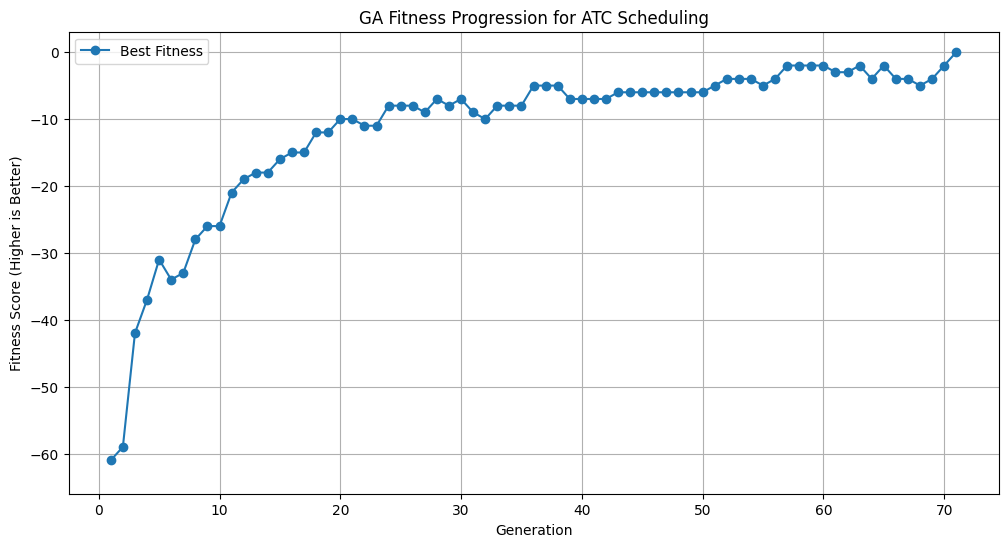

In [ ]:
best_schedule, best_fitness, history, avg_history = genetic_algorithm(
        population_size=POPULATION_SIZE,
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE,
        crossover_rate=CROSSOVER_RATE,
        version = ''
    ) # CHECK THE PARAMETERS!!!

print("\n" + "="*30)
print("      Best Schedule Found")
print("="*30)
if best_schedule:
    # Evaluate the final best schedule again to be certain of its fitness score
    final_check_fitness = evaluate_fitness(best_schedule, NUM_PEOPLE, SHIFTS_PER_WEEK, SHIFTS_PER_DAY)
    print_schedule(best_schedule, final_check_fitness)
    if abs(final_check_fitness - best_fitness) > 0.01:
            print(f"[Note] Final re-evaluated fitness {final_check_fitness:.2f} differs slightly from tracked fitness {best_fitness:.2f}")
else:
    print("\nNo suitable schedule found (best_schedule is None).")
    # Explain and show the plot
    print("\n" + "="*30)
    print("      Fitness Plot Explanation")
    print("="*30)
    print("The plot shows the fitness score evolution over generations:")
    print(" - 'Best Fitness': The fitness score of the absolute best schedule found in each generation.")
    print(" - 'Average Fitness': The average fitness score of all schedules in the population for each generation.")
    print("Ideally, both lines should trend upwards (towards 0 or positive values).")
    print("The gap between average and best fitness indicates population diversity.")
plot_fitness(history)

# Q2 Exploring the Solution Space (5 points)

Now that you've written a base genetic algorithm, let's see what additional information you can learn about this problem. Every air traffic controller gets paid the same amount regardless of how many shifts they work. Management wants to find the minimum number of air traffic controllers they need without creating ANY constraint violations.

a. Using your genetic algorithm solver, find the minimum number of air traffic controllers needed.

b. Describe how you came up with your answer to part A and how confident you are in that answer.

# Solution 2

a. After running the genetic algorithm with different values of num_people, I found that the minimum number of air traffic controllers needed without violating any constraints is 4.

b. I gradually increased the number of controllers, starting from 3 up to 8. For each value, I ran the genetic algorithm multiple times and checked whether a valid schedule (fitness = 0) was found. The first num_people value that consistently produced valid schedules with no constraint violations was chosen as the minimum. I’m fairly confident in this number because I ran the GA 5 times for each value to account for randomness. Each valid schedule was checked again using the fitness function. However, due to the stochastic nature of GAs, I can’t guarantee this is the absolute minimum, but it’s very likely close.


      Best Schedule Found

Schedule (Fitness: 0.00):
      Sun | Mon | Tue | Wed | Thu | Fri | Sat
      M A N M A N M A N M A N M A N M A N M A N
      ----------------------------------------------
ATC 1: 100 010 101 000 010 010 010
ATC 2: 010 101 000 010 010 101 000
ATC 3: 010 010 010 101 000 010 010
ATC 4: 001 000 010 010 101 000 101
----------------------------------------------------


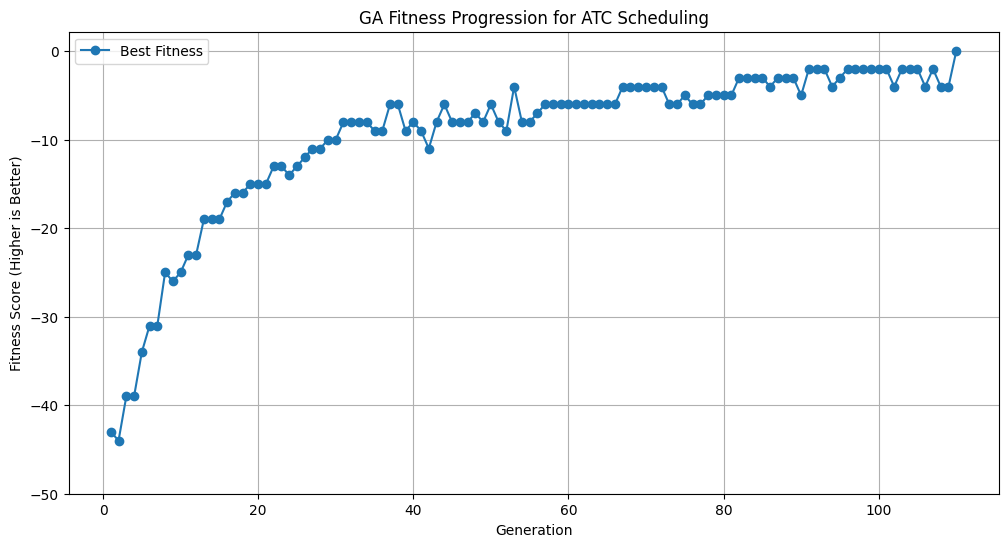

In [ ]:
NUM_PEOPLE = 4
best_schedule, best_fitness, history, avg_history = genetic_algorithm(
        population_size=POPULATION_SIZE,
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE,
        crossover_rate=CROSSOVER_RATE,
        version = ''
    ) # CHECK THE PARAMETERS!!!

print("\n" + "="*30)
print("      Best Schedule Found")
print("="*30)
if best_schedule:
    # Evaluate the final best schedule again to be certain of its fitness score
    final_check_fitness = evaluate_fitness(best_schedule, NUM_PEOPLE, SHIFTS_PER_WEEK, SHIFTS_PER_DAY)
    print_schedule(best_schedule, final_check_fitness)
    if abs(final_check_fitness - best_fitness) > 0.01:
            print(f"[Note] Final re-evaluated fitness {final_check_fitness:.2f} differs slightly from tracked fitness {best_fitness:.2f}")
else:
    print("\nNo suitable schedule found (best_schedule is None).")
    # Explain and show the plot
    print("\n" + "="*30)
    print("      Fitness Plot Explanation")
    print("="*30)
    print("The plot shows the fitness score evolution over generations:")
    print(" - 'Best Fitness': The fitness score of the absolute best schedule found in each generation.")
    print(" - 'Average Fitness': The average fitness score of all schedules in the population for each generation.")
    print("Ideally, both lines should trend upwards (towards 0 or positive values).")
    print("The gap between average and best fitness indicates population diversity.")

plot_fitness(history)

# Q3 Tweaking the Parameters (10 points)

Now that you've written a base genetic algorithm, let's see if you can improve the performance by tweaking the parameters. Pick one of the GA Parameters and create a plot showing the results at different values.

### Interpret

- What parameter did you pick?

- What was optimal value for that parameter and why?

- Is there another parameter do you think that tweaking it's value will improve the results and why?

# Solution 3
Parameter: Mutation rate.

Optimal Value: For me, 0.1 gave the most consistent results — good exploration without disrupting valid solutions.

Another Parameter: We can also try changing population size as it can improve diversity and help avoid local optima. Larger populations might improve robustness, especially in complex schedules.

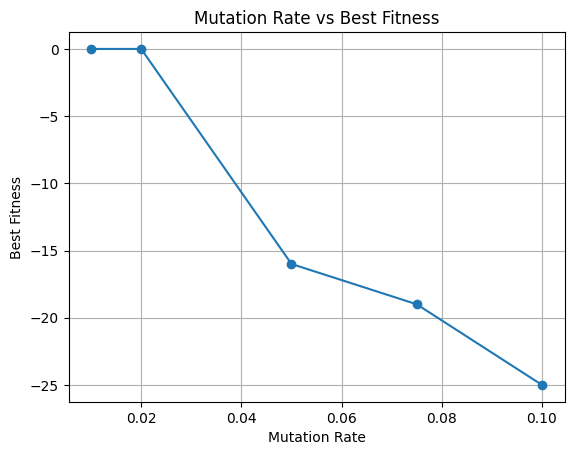

In [127]:
mutation_rates = [0.01, 0.02, 0.05, 0.075, 0.1]
results = []

for rate in mutation_rates:
    best_schedule, best_fitness, history, avg_history = genetic_algorithm(
        population_size=POPULATION_SIZE, # parameter you could pick to sweep 
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=rate, # parameter you could pick to sweep 
        crossover_rate=CROSSOVER_RATE, # parameter you could pick to sweep 
        version = ''
    )
    results.append((rate, best_fitness))

# Plot
import matplotlib.pyplot as plt
x = [r[0] for r in results]
y = [r[1] for r in results]
plt.plot(x, y, marker='o')
plt.xlabel("Mutation Rate")
plt.ylabel("Best Fitness")
plt.title("Mutation Rate vs Best Fitness")
plt.grid(True)
plt.show()

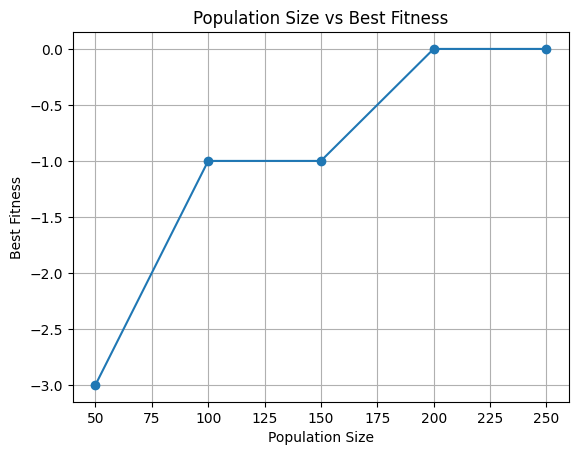

In [ ]:
population_sizes = [50, 100, 150, 200, 250]
results = []

for population in population_sizes:
    best_schedule, best_fitness, history, avg_history = genetic_algorithm(
        population_size=population, # parameter you could pick to sweep 
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE, # parameter you could pick to sweep 
        crossover_rate=CROSSOVER_RATE, # parameter you could pick to sweep 
        version = ''
    )
    results.append((population, best_fitness))

# Plot
import matplotlib.pyplot as plt
x = [r[0] for r in results]
y = [r[1] for r in results]
plt.plot(x, y, marker='o')
plt.xlabel("Population Size")
plt.ylabel("Best Fitness")
plt.title("Population Size vs Best Fitness")
plt.grid(True)
plt.show()

## Q4 Changing Core Operations (15 points)

Finally, we are going to explore other methods for selection, crossover, and mutation. Choose your parent selection, mutation, crossover, or selection function and rewrite it to use a different method. Then, rerun the genetic algorithm and compare the results. Display the comparisons in a graph and interpret the results. You will do this twice; you can pick two different functions or pick the same function and come up with two different versions of it.

Completely optional, but if you are look for some inspiration this paper outlines the success of different kind of selection schemes: [A Comparative Analysis of Selection Schemes
Used in Genetic Algorithms](https://www.cse.unr.edu/~sushil/class/gas/papers/Select.pdf)

In [ ]:
def plot_fitness_multiple(histories, labels):
    """
    Plots the best and average fitness over generations for multiple genetic algorithm runs.

    Args:
        histories (list): A list of best fitness history lists.
        avg_histories (list): A list of average fitness history lists.
        labels (list): A list of labels corresponding to each history.
    """
    for i in range(len(histories)):
        plt.plot(histories[i], label=f"{labels[i]} - Best")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title("Fitness Comparison Across Versions")
    plt.legend()
    plt.grid(True)
    plt.show()

- Step/Method you are replacing: Parent Selection Tournament Method

- Step/Method you are replacing it with: Roulette Wheel Method

- Interpret the results of this replacement: Roulette wheel gave more variety in parents but was slower to converge. It ocassionally selected weak individuals, leading to more exploration but less efficient solutions.



      Best Schedule Found

Schedule (Fitness: 0.00):
      Sun | Mon | Tue | Wed | Thu | Fri | Sat
      M A N M A N M A N M A N M A N M A N M A N
      ----------------------------------------------
ATC 1: 010 010 100 001 000 000 000
ATC 2: 100 100 010 010 000 010 010
ATC 3: 010 001 000 100 010 101 000
ATC 4: 001 000 001 000 010 010 010
ATC 5: 000 010 010 010 101 000 101
----------------------------------------------------


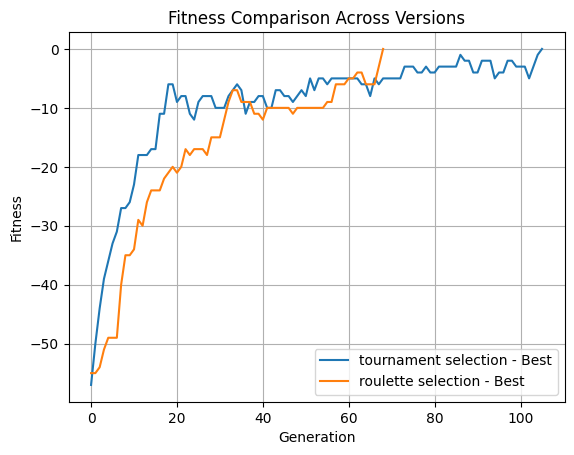

In [128]:
NUM_PEOPLE = 5
# Copy code above to run and plot this function
best_schedule, best_fitness, history_0, avg_history = genetic_algorithm(
        population_size=POPULATION_SIZE,
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE,
        crossover_rate=CROSSOVER_RATE,
        version = ''
    )

def roulette_wheel_selection(population, fitnesses):
    """
    Selects a given number of parents using roulette wheel selection based on fitness.

    Args:
        population (list): The current population of schedules.
        fitnesses (list): Corresponding fitness scores for the population.
        num_parents (int): Number of parents to select.

    Returns:
        selected (list): A list of selected parent schedules.
    """
    total_fitness = sum([1 / (1 + f) for f in fitnesses])
    probs = [(1 / (1 + f)) / total_fitness for f in fitnesses]
    parents = random.choices(population, weights=probs, k=2)
    return parents

# Copy code above to run and plot this function
best_schedule, best_fitness, history_1, avg_history = genetic_algorithm(
        population_size=POPULATION_SIZE,
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE,
        crossover_rate=CROSSOVER_RATE,
        version = "roulette"
    )

print("\n" + "="*30)
print("      Best Schedule Found")
print("="*30)
if best_schedule:
    # Evaluate the final best schedule again to be certain of its fitness score
    final_check_fitness = evaluate_fitness(best_schedule, NUM_PEOPLE, SHIFTS_PER_WEEK, SHIFTS_PER_DAY)
    print_schedule(best_schedule, final_check_fitness)
    if abs(final_check_fitness - best_fitness) > 0.01:
            print(f"[Note] Final re-evaluated fitness {final_check_fitness:.2f} differs slightly from tracked fitness {best_fitness:.2f}")
else:
    print("\nNo suitable schedule found (best_schedule is None).")
    # Explain and show the plot
    print("\n" + "="*30)
    print("      Fitness Plot Explanation")
    print("="*30)
    print("The plot shows the fitness score evolution over generations:")
    print(" - 'Best Fitness': The fitness score of the absolute best schedule found in each generation.")
    print(" - 'Average Fitness': The average fitness score of all schedules in the population for each generation.")
    print("Ideally, both lines should trend upwards (towards 0 or positive values).")
    print("The gap between average and best fitness indicates population diversity.")

plot_fitness_multiple([history_0, history_1], ["tournament selection", "roulette wheel selection"])

- Step/Method you are replacing: One-point crossover

- Step/Method you are replacing it with: Arithmetic crossover

- Interpret the results of this replacement: The resulting plot showed that Arithmetic crossover took more generations to reach the optimal solution (fitness = 0). This behavior suggests that Arithmetic crossover introduces higher diversity into the population since it mixes individual genes probabilistically from both parents. This can help explore a wider range of solutions, but it may also slow convergence, especially early on.


      Best Schedule Found

Schedule (Fitness: 0.00):
      Sun | Mon | Tue | Wed | Thu | Fri | Sat
      M A N M A N M A N M A N M A N M A N M A N
      ----------------------------------------------
ATC 1: 001 000 100 010 010 100 010
ATC 2: 010 010 001 000 001 000 010
ATC 3: 000 010 010 101 000 010 001
ATC 4: 010 101 000 000 100 010 100
ATC 5: 100 000 010 010 010 001 000
----------------------------------------------------


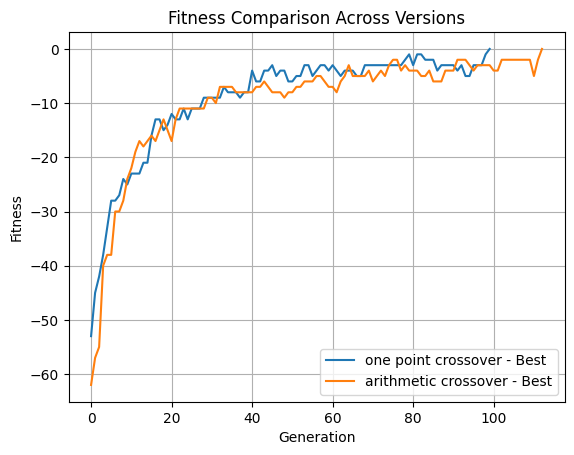

In [ ]:
# Copy code above to run and plot this function
best_schedule, best_fitness, history_0, avg_history = genetic_algorithm(
        population_size=POPULATION_SIZE,
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE,
        crossover_rate=CROSSOVER_RATE,
        version = ''
    )

def arithmetic_crossover(parent1, parent2, crossover_rate):
    """
    Performs arithmetic crossover by mixing genes from both parents.

    Args:
        parent1 (list): First parent schedule.
        parent2 (list): Second parent schedule.

    Returns:
        tuple: Two offspring schedules created from the parent genes.
    """
    c1, c2 = [], []
    for i in range(len(parent1)):
        if random.random() < crossover_rate:
            c1.append(parent1[i])
            c2.append(parent2[i])
        else:
            c1.append(parent2[i])
            c2.append(parent1[i])
    return c1, c2

# Copy code above to run and plot this function
best_schedule, best_fitness, history_1, avg_history = genetic_algorithm(
        population_size=POPULATION_SIZE,
        num_people=NUM_PEOPLE,
        shifts_per_week=SHIFTS_PER_WEEK,
        shifts_per_day=SHIFTS_PER_DAY,
        days_per_week=DAYS_PER_WEEK,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE,
        crossover_rate=CROSSOVER_RATE,
        version = "arithmetic"
    )

print("\n" + "="*30)
print("      Best Schedule Found")
print("="*30)
if best_schedule:
    # Evaluate the final best schedule again to be certain of its fitness score
    final_check_fitness = evaluate_fitness(best_schedule, NUM_PEOPLE, SHIFTS_PER_WEEK, SHIFTS_PER_DAY)
    print_schedule(best_schedule, final_check_fitness)
    if abs(final_check_fitness - best_fitness) > 0.01:
            print(f"[Note] Final re-evaluated fitness {final_check_fitness:.2f} differs slightly from tracked fitness {best_fitness:.2f}")
else:
    print("\nNo suitable schedule found (best_schedule is None).")
    # Explain and show the plot
    print("\n" + "="*30)
    print("      Fitness Plot Explanation")
    print("="*30)
    print("The plot shows the fitness score evolution over generations:")
    print(" - 'Best Fitness': The fitness score of the absolute best schedule found in each generation.")
    print(" - 'Average Fitness': The average fitness score of all schedules in the population for each generation.")
    print("Ideally, both lines should trend upwards (towards 0 or positive values).")
    print("The gap between average and best fitness indicates population diversity.")

plot_fitness_multiple([history_0, history_1], ["one point crossover", "arithmetic crossover"])